# Day 15: Edtech Student Performance Visualiser

**Industry:** Education / Edtech  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · seaborn · matplotlib · correlation · groupby · subplots

**Data:** UCI Student Performance Dataset — real Portuguese secondary school data  
395 Math students + 649 Portuguese students · 33 features each

---

## Who uses this
A **school principal or head of year** deciding where to allocate tutoring resources. Instead of reviewing individual grade sheets, this dashboard surfaces systemic patterns — which factors correlate with failure, which groups are most at risk, and where intervention would have the most impact.

## Problem
Teachers have grade data but no visual way to spot learning gaps across cohorts. A student failing G3 (final grade) often showed warning signs in G1 and G2 — and in factors like study time, absences, and family background — that went unnoticed without analysis.

## What we build
1. Load both Math and Portuguese datasets and combine
2. Clean and engineer features
3. Grade distribution and failure rate analysis
4. Key factor analysis — study time, absences, alcohol, family support
5. Correlation heatmap of all numeric features vs final grade
6. 6-panel seaborn dashboard
7. At-risk student list export

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Combine Both Datasets

In [2]:
mat = pd.read_csv('student-mat.csv', sep=';')
por = pd.read_csv('student-por.csv', sep=';')

mat['subject'] = 'Math'
por['subject'] = 'Portuguese'

df = pd.concat([mat, por], ignore_index=True)

print(f'Math students:       {len(mat)}')
print(f'Portuguese students: {len(por)}')
print(f'Combined total:      {len(df)}')
print(f'Features:            {len(df.columns)}')
print(f'\nNull counts: {df.isnull().sum().sum()} total nulls')
print(f'\nGrade stats (G3 = final grade):')
print(df['G3'].describe().round(2).to_string())
df.head(3)

Math students:       395
Portuguese students: 649
Combined total:      1044
Features:            34

Null counts: 0 total nulls

Grade stats (G3 = final grade):
count    1044.00
mean       11.34
std         3.86
min         0.00
25%        10.00
50%        11.00
75%        14.00
max        20.00


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math


## Step 3 — Clean and Engineer Features

In [3]:
# Convert G1, G2, G3 to numeric (some may be quoted strings)
for col in ['G1', 'G2', 'G3']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Failure flag — G3 < 10 is failing in Portuguese grading system (0-20)
df['failed'] = (df['G3'] < 10).astype(int)

# Average grade across all three periods
df['avg_grade'] = ((df['G1'] + df['G2'] + df['G3']) / 3).round(2)

# Grade improvement from G1 to G3
df['grade_trend'] = df['G3'] - df['G1']

# Grade band
df['grade_band'] = pd.cut(
    df['G3'],
    bins=[-1, 9, 12, 15, 20],
    labels=['Fail (<10)', 'Pass (10-12)', 'Good (13-15)', 'Excellent (16-20)']
)

# Study time labels
study_map = {1: '<2 hrs', 2: '2-5 hrs', 3: '5-10 hrs', 4: '>10 hrs'}
df['studytime_label'] = df['studytime'].map(study_map)

# Alcohol risk (combined weekday + weekend)
df['alcohol_total'] = df['Dalc'] + df['Walc']

overall_fail_rate = df['failed'].mean() * 100
print(f'Overall failure rate (G3 < 10): {overall_fail_rate:.1f}%')
print(f'Math failure rate:              {mat["G3"].lt(10).mean()*100:.1f}%')
print(f'Portuguese failure rate:        {por["G3"].lt(10).mean()*100:.1f}%')
print(f'\nGrade band distribution:')
print(df['grade_band'].value_counts().sort_index().to_string())
print(f'\nAvg G3 by subject:')
print(df.groupby('subject')['G3'].mean().round(2).to_string())

Overall failure rate (G3 < 10): 22.0%
Math failure rate:              32.9%
Portuguese failure rate:        15.4%

Grade band distribution:
grade_band
Fail (<10)           230
Pass (10-12)         407
Good (13-15)         285
Excellent (16-20)    122

Avg G3 by subject:
subject
Math          10.42
Portuguese    11.91


## Step 4 — Factor Analysis

Which factors most strongly predict final grade? We examine study time, absences, alcohol, family support, and past failures.

In [4]:
# Avg G3 by study time
study_perf = df.groupby('studytime')['G3'].agg(['mean','count']).round(2)
study_perf.index = study_perf.index.map(study_map)

# Avg G3 by number of past failures
failure_perf = df.groupby('failures')['G3'].agg(['mean','count']).round(2)

# Fail rate by internet access
internet_perf = df.groupby('internet')['failed'].agg(['mean','count'])
internet_perf['mean'] = (internet_perf['mean'] * 100).round(1)

# Avg G3 by higher education aspiration
higher_perf = df.groupby('higher')['G3'].mean().round(2)

# Correlation of numeric features with G3
numeric_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                'famrel','freetime','goout','Dalc','Walc','health',
                'absences','G1','G2','alcohol_total']
correlations = df[numeric_cols + ['G3']].corr()['G3'].drop('G3').sort_values()

print('=== Avg G3 by study time ===')
print(study_perf.to_string())
print('\n=== Avg G3 by past failures ===')
print(failure_perf.to_string())
print('\n=== Fail rate by internet access ===')
print(internet_perf.to_string())
print('\n=== Top correlations with G3 ===')
print(correlations.round(3).to_string())

=== Avg G3 by study time ===
            mean  count
studytime              
<2 hrs     10.58    317
2-5 hrs    11.34    503
5-10 hrs   12.49    162
>10 hrs    12.27     62

=== Avg G3 by past failures ===
           mean  count
failures              
0         12.05    861
1          8.43    120
2          7.48     33
3          6.80     30

=== Fail rate by internet access ===
          mean  count
internet             
no        26.7    217
yes       20.8    827

=== Top correlations with G3 ===
failures        -0.383
alcohol_total   -0.134
Dalc            -0.130
age             -0.125
Walc            -0.116
traveltime      -0.103
goout           -0.098
health          -0.080
freetime        -0.065
absences        -0.046
famrel           0.054
Fedu             0.160
studytime        0.162
Medu             0.201
G1               0.809
G2               0.911


## Step 5 — At-Risk Student Identification

We flag students showing multiple risk signals — low G1/G2, high absences, past failures, low study time. This is the intervention priority list.

In [5]:
df['risk_score'] = (
    (df['G1'] < 10).astype(int) * 3 +
    (df['G2'] < 10).astype(int) * 3 +
    (df['failures'] > 0).astype(int) * 2 +
    (df['absences'] > 10).astype(int) * 1 +
    (df['studytime'] == 1).astype(int) * 1 +
    (df['higher'] == 'no').astype(int) * 1
)

at_risk = (
    df[df['risk_score'] >= 5]
    [['subject','sex','age','G1','G2','G3','failures','absences',
      'studytime_label','higher','risk_score']]
    .sort_values('risk_score', ascending=False)
    .reset_index(drop=True)
)

print(f'Students flagged at-risk (score >= 5): {len(at_risk)}')
print(f'Of these, already failed G3:           {(at_risk["G3"] < 10).sum()}')
print(f'\nTop 10 highest risk students:')
print(at_risk.head(10).to_string())

Students flagged at-risk (score >= 5): 270
Of these, already failed G3:           193

Top 10 highest risk students:
      subject sex  age  G1  G2  G3  failures  absences studytime_label higher  risk_score
0  Portuguese   M   22   7   8   5         3        12          <2 hrs     no          11
1  Portuguese   M   17   6   7   7         1        12          <2 hrs     no          11
2  Portuguese   M   18   7   8   8         1        26          <2 hrs     no          11
3  Portuguese   F   18   8   7   7         1        14          <2 hrs     no          11
4        Math   M   22   6   8   8         3        16          <2 hrs     no          11
5        Math   M   17   7   6   0         2         0          <2 hrs     no          10
6  Portuguese   M   18   7   8   6         2         4          <2 hrs     no          10
7  Portuguese   F   17   6   6   7         1         0          <2 hrs     no          10
8  Portuguese   M   18   8   9  10         1         0          <2 hrs   

## Step 6 — Visualise: 6-Panel Dashboard

Dashboard saved as student_performance_dashboard.png


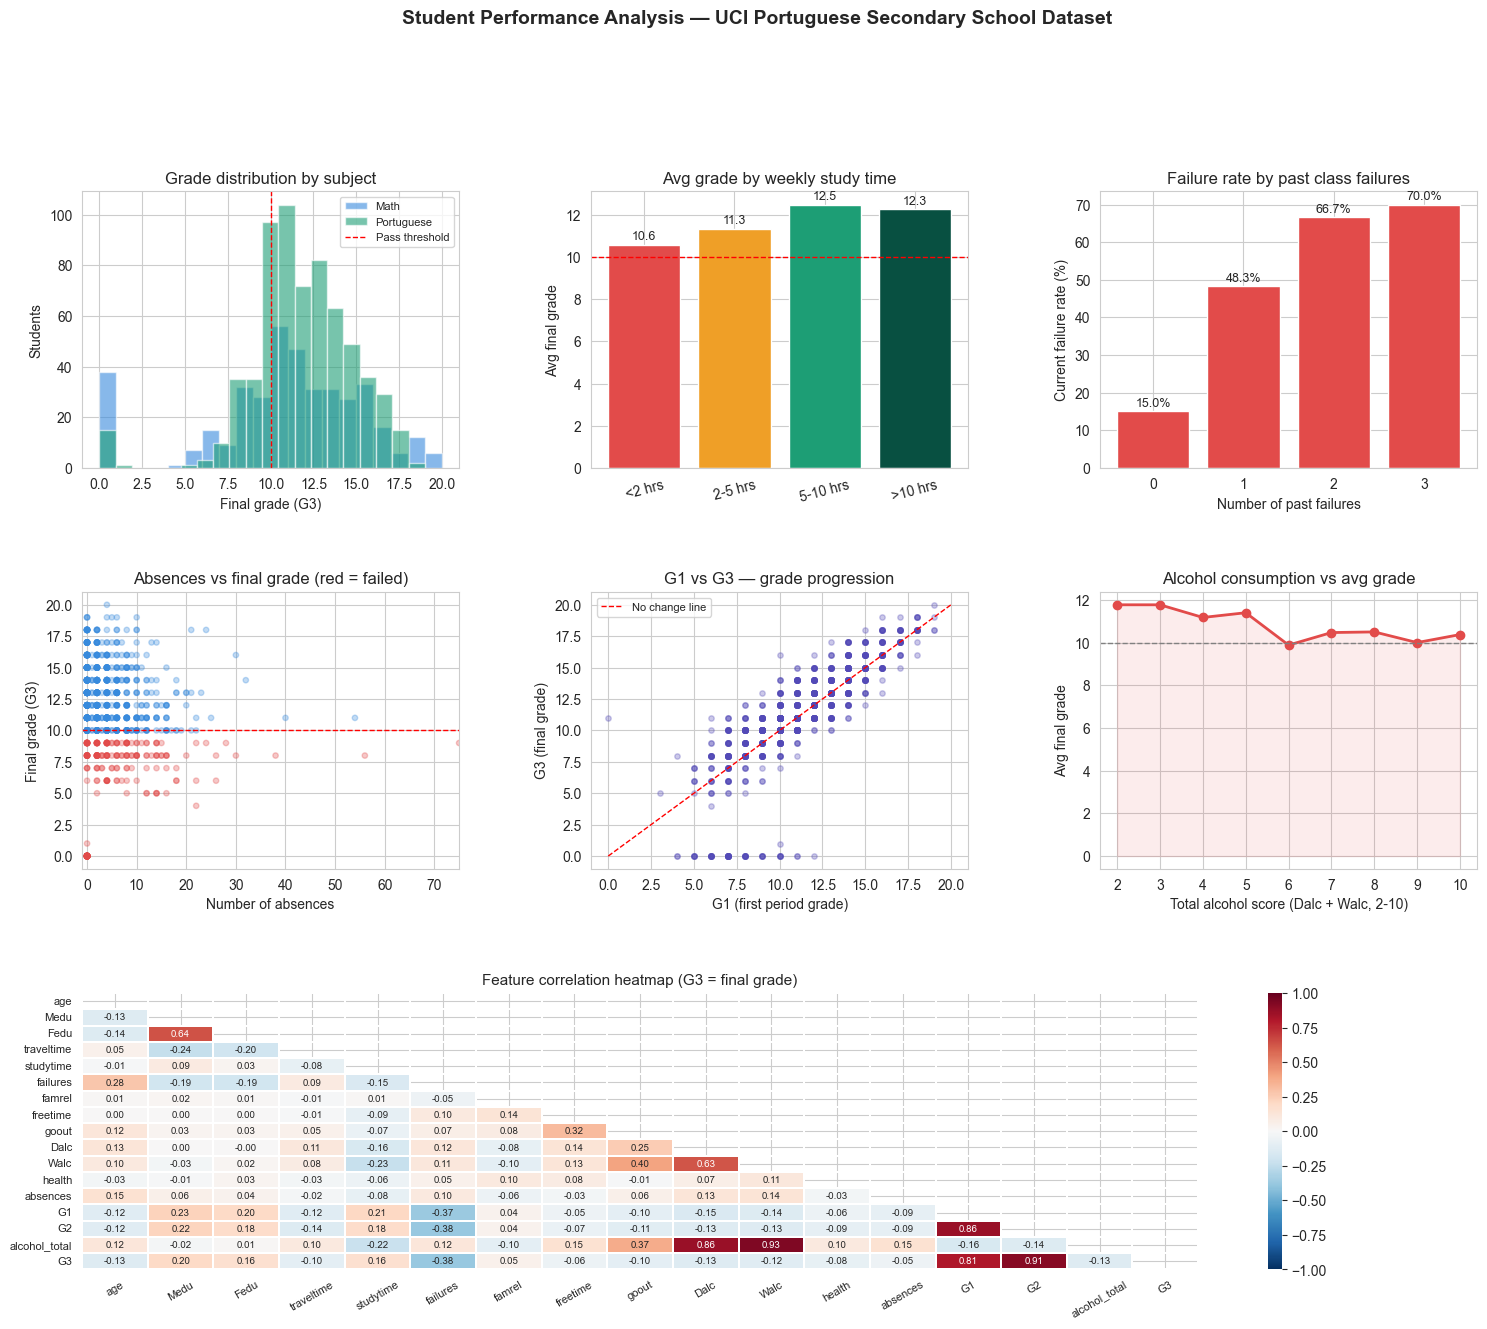

In [6]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Student Performance Analysis — UCI Portuguese Secondary School Dataset',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel 1 — Grade distribution by subject
ax1 = fig.add_subplot(gs[0, 0])
for subj, color in [('Math', '#378ADD'), ('Portuguese', '#1D9E75')]:
    subset = df[df['subject'] == subj]['G3']
    ax1.hist(subset, bins=20, alpha=0.6, color=color, label=subj, edgecolor='white')
ax1.axvline(10, color='red', linestyle='--', linewidth=1, label='Pass threshold')
ax1.set_xlabel('Final grade (G3)')
ax1.set_ylabel('Students')
ax1.set_title('Grade distribution by subject')
ax1.legend(fontsize=8)

# Panel 2 — Avg G3 by study time
ax2 = fig.add_subplot(gs[0, 1])
order = ['<2 hrs', '2-5 hrs', '5-10 hrs', '>10 hrs']
study_vals = df.groupby('studytime_label')['G3'].mean().reindex(order)
colors2 = ['#E24B4A', '#EF9F27', '#1D9E75', '#085041']
bars = ax2.bar(order, study_vals, color=colors2)
ax2.axhline(10, color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Avg final grade')
ax2.set_title('Avg grade by weekly study time')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, study_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Panel 3 — Fail rate by past failures
ax3 = fig.add_subplot(gs[0, 2])
fail_by_fail = df.groupby('failures')['failed'].mean() * 100
ax3.bar(fail_by_fail.index.astype(str), fail_by_fail.values, color='#E24B4A')
ax3.set_xlabel('Number of past failures')
ax3.set_ylabel('Current failure rate (%)')
ax3.set_title('Failure rate by past class failures')
for i, val in enumerate(fail_by_fail.values):
    ax3.text(i, val+0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Panel 4 — Absences vs G3 scatter
ax4 = fig.add_subplot(gs[1, 0])
colors_scatter = ['#E24B4A' if f else '#378ADD' for f in df['failed']]
ax4.scatter(df['absences'], df['G3'], c=colors_scatter, alpha=0.3, s=15)
ax4.axhline(10, color='red', linestyle='--', linewidth=1)
ax4.set_xlabel('Number of absences')
ax4.set_ylabel('Final grade (G3)')
ax4.set_title('Absences vs final grade (red = failed)')
ax4.set_xlim(-1, 75)

# Panel 5 — G1 vs G3 progression
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['G1'], df['G3'], alpha=0.3, s=15, color='#534AB7')
ax5.plot([0, 20], [0, 20], 'r--', linewidth=1, label='No change line')
ax5.set_xlabel('G1 (first period grade)')
ax5.set_ylabel('G3 (final grade)')
ax5.set_title('G1 vs G3 — grade progression')
ax5.legend(fontsize=8)

# Panel 6 — Alcohol vs avg grade
ax6 = fig.add_subplot(gs[1, 2])
alc_perf = df.groupby('alcohol_total')['G3'].mean().reset_index()
ax6.plot(alc_perf['alcohol_total'], alc_perf['G3'],
         color='#E24B4A', linewidth=2, marker='o', markersize=6)
ax6.fill_between(alc_perf['alcohol_total'], alc_perf['G3'], alpha=0.1, color='#E24B4A')
ax6.axhline(10, color='gray', linestyle='--', linewidth=1)
ax6.set_xlabel('Total alcohol score (Dalc + Walc, 2-10)')
ax6.set_ylabel('Avg final grade')
ax6.set_title('Alcohol consumption vs avg grade')

# Panel 7 — Correlation heatmap (bottom full width)
ax7 = fig.add_subplot(gs[2, :])
corr_matrix = df[numeric_cols + ['G3']].corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax7,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3)
ax7.set_title('Feature correlation heatmap (G3 = final grade)', fontsize=11)
ax7.tick_params(axis='x', rotation=30, labelsize=8)
ax7.tick_params(axis='y', rotation=0, labelsize=8)

plt.savefig('student_performance_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as student_performance_dashboard.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

at_risk.to_csv('output/at_risk_students.csv', index=False)
correlations.round(3).to_csv('output/grade_correlations.csv')
study_perf.to_csv('output/grade_by_study_time.csv')

top_corr    = correlations.abs().sort_values(ascending=False)
best_factor = top_corr.index[0]
worst_alc   = alc_perf.iloc[-1]
best_alc    = alc_perf.iloc[0]

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Total students analysed:    {len(df):,}')
print(f'Math students:              {len(mat)}')
print(f'Portuguese students:        {len(por)}')
print(f'Overall failure rate:       {overall_fail_rate:.1f}%')
print(f'Math failure rate:          {mat["G3"].lt(10).mean()*100:.1f}%')
print(f'Portuguese failure rate:    {por["G3"].lt(10).mean()*100:.1f}%')
print()
print(f'Strongest predictor of G3:  {best_factor} (r={correlations[best_factor]:.3f})')
print(f'Weakest factor:             {correlations.abs().idxmin()}')
print()
print(f'Study time impact:')
print(f'  <2 hrs/week avg grade:    {study_vals["<2 hrs"]:.1f}')
print(f'  >10 hrs/week avg grade:   {study_vals[">10 hrs"]:.1f}')
print(f'  Difference:               +{study_vals[">10 hrs"] - study_vals["<2 hrs"]:.1f} grade points')
print()
print(f'Alcohol impact:')
print(f'  Lowest consumption avg:   {best_alc["G3"]:.1f}')
print(f'  Highest consumption avg:  {worst_alc["G3"]:.1f}')
print()
print(f'At-risk students flagged:   {len(at_risk)}')
print(f'Already failing (G3<10):    {(at_risk["G3"]<10).sum()}')
print()
print('RECOMMENDATIONS FOR SCHOOL PRINCIPAL:')
print(f'  1. {len(at_risk)} students flagged — prioritise tutoring support')
print(f'  2. G2 is strongest G3 predictor — intervene after period 2')
print(f'  3. Study time <2 hrs linked to avg grade {study_vals["<2 hrs"]:.1f} — promote study habits')
print(f'  4. Past failures strongest risk signal — target repeat-failure students early')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Total students analysed:    1,044
Math students:              395
Portuguese students:        649
Overall failure rate:       22.0%
Math failure rate:          32.9%
Portuguese failure rate:    15.4%

Strongest predictor of G3:  G2 (r=0.911)
Weakest factor:             absences

Study time impact:
  <2 hrs/week avg grade:    10.6
  >10 hrs/week avg grade:   12.3
  Difference:               +1.7 grade points

Alcohol impact:
  Lowest consumption avg:   11.8
  Highest consumption avg:  10.4

At-risk students flagged:   270
Already failing (G3<10):    193

RECOMMENDATIONS FOR SCHOOL PRINCIPAL:
  1. 270 students flagged — prioritise tutoring support
  2. G2 is strongest G3 predictor — intervene after period 2
  3. Study time <2 hrs linked to avg grade 10.6 — promote study habits
  4. Past failures strongest risk signal — target repeat-failure students early


## Summary

### What we built
A student performance analysis dashboard on real Portuguese secondary school data — from raw grades to an at-risk student intervention list with factor analysis and correlation heatmap.

### Skills practised
- `pandas` — multi-file load, concat, pd.cut, groupby, agg, correlation
- `seaborn` — heatmap with mask
- `matplotlib` — GridSpec 6-panel layout, scatter, hist, bar, line
- Risk scoring — rule-based weighted model
- Education metrics — failure rate, grade progression, factor correlation

### Key findings
Fill these in from your output:
- Overall failure rate: 22.0%
- Strongest predictor of G3: G2 (r=0.911)
- Study time impact (low vs high): +1.7 grade points
- At-risk students flagged: 270
- Math vs Portuguese failure rates: 32.9%, 15.4%